In [1]:
"""
Code the Cup — Match Predictor (single self-contained file / Colab cell)
Run:  python predictor.py     or paste the whole thing into ONE Colab cell and run.
Deps: pip install pandas numpy scikit-learn   (in Colab: !pip install scikit-learn)

data -> Elo(+home adv) & rolling form -> compare models -> calibration -> final + plain-English why
"""
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, log_loss

URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
FEATURES = ["elo_diff", "form_pts_diff", "home_form_gd", "away_form_gd", "neutral_flag"]

KO_2026 = [  # 2026 WC knockout results, appended only if the dataset lacks 2026 WC matches
 ("2026-06-28","Canada","South Africa",1,0),("2026-06-28","Brazil","Japan",2,1),
 ("2026-06-29","Paraguay","Germany",1,1),("2026-06-29","Morocco","Netherlands",1,1),
 ("2026-06-30","Norway","Ivory Coast",2,1),("2026-06-30","France","Sweden",3,0),
 ("2026-06-30","Mexico","Ecuador",2,0),("2026-07-01","England","DR Congo",2,1),
 ("2026-07-01","Belgium","Senegal",3,2),("2026-07-01","United States","Bosnia and Herzegovina",2,0),
 ("2026-07-02","Spain","Austria",3,0),("2026-07-02","Portugal","Croatia",2,1),
 ("2026-07-02","Switzerland","Algeria",2,0),("2026-07-03","Egypt","Australia",1,1),
 ("2026-07-03","Argentina","Cape Verde",3,2),("2026-07-03","Colombia","Ghana",1,0),
 ("2026-07-04","Morocco","Canada",3,0),("2026-07-04","France","Paraguay",1,0),
 ("2026-07-05","Norway","Brazil",2,1),("2026-07-05","England","Mexico",3,2),
 ("2026-07-06","Spain","Portugal",1,0),("2026-07-06","Belgium","United States",4,1),
 ("2026-07-07","Argentina","Egypt",3,2),("2026-07-07","Switzerland","Colombia",0,0),
 ("2026-07-09","France","Morocco",2,0),("2026-07-10","Spain","Belgium",2,1),
 ("2026-07-11","England","Norway",2,1),("2026-07-11","Argentina","Switzerland",3,1),
 ("2026-07-14","Spain","France",2,0),("2026-07-15","Argentina","England",2,1),
]


def load_data():
    src = os.environ.get("WC_DATA", URL)
    print(f"[load] reading {src}")
    df = pd.read_csv(src, parse_dates=["date"])
    df = df.dropna(subset=["home_score", "away_score"]).sort_values("date").reset_index(drop=True)
    df["neutral"] = df["neutral"].map(
        lambda x: x if isinstance(x, bool) else str(x).strip().lower() in ("true", "1", "t", "yes"))
    print(f"[load] {len(df):,} matches, {df.date.min().date()} -> {df.date.max().date()}")
    wc26 = df[(df.tournament.str.contains("World Cup", case=False, na=False)) & (df.date.dt.year == 2026)]
    if len(wc26) < 20:
        add = pd.DataFrame(KO_2026, columns=["date", "home_team", "away_team", "home_score", "away_score"])
        add["date"] = pd.to_datetime(add["date"]); add["tournament"] = "FIFA World Cup"; add["neutral"] = True
        for c in df.columns:
            if c not in add.columns:
                add[c] = np.nan
        df = pd.concat([df, add[df.columns]], ignore_index=True).sort_values("date").reset_index(drop=True)
        print(f"[load] appended {len(add)} 2026 WC knockout matches (dataset had {len(wc26)})")
    else:
        print(f"[load] dataset already has {len(wc26)} 2026 WC matches; not appending")
    return df


def add_features(df, K=30, HOME_ADV=65, base=1500.0, form_n=5):
    df = df.copy()
    df["result"] = np.select([df.home_score > df.away_score, df.home_score == df.away_score], ["H", "D"], "A")
    elo, hE, aE = {}, [], []
    for r in df.itertuples():
        Rh, Ra = elo.get(r.home_team, base), elo.get(r.away_team, base)
        adv = 0 if r.neutral else HOME_ADV
        exp_h = 1 / (1 + 10 ** ((Ra - (Rh + adv)) / 400))
        hE.append(Rh); aE.append(Ra)
        s_h = 1.0 if r.result == "H" else 0.5 if r.result == "D" else 0.0
        mov = np.log1p(abs(r.home_score - r.away_score))
        elo[r.home_team] = Rh + K * mov * (s_h - exp_h)
        elo[r.away_team] = Ra + K * mov * ((1 - s_h) - (1 - exp_h))
    df["home_elo"], df["away_elo"] = hE, aE
    df["elo_diff"] = df.home_elo - df.away_elo
    pts, gd, hp, ap, hgd, agd = {}, {}, [], [], [], []
    for r in df.itertuples():
        hp.append(np.mean(pts.get(r.home_team, [1.0])[-form_n:]))
        ap.append(np.mean(pts.get(r.away_team, [1.0])[-form_n:]))
        hgd.append(np.mean(gd.get(r.home_team, [0.0])[-form_n:]))
        agd.append(np.mean(gd.get(r.away_team, [0.0])[-form_n:]))
        ph = 3 if r.result == "H" else 1 if r.result == "D" else 0
        pts.setdefault(r.home_team, []).append(ph)
        pts.setdefault(r.away_team, []).append(3 - ph if ph != 1 else 1)
        gd.setdefault(r.home_team, []).append(r.home_score - r.away_score)
        gd.setdefault(r.away_team, []).append(r.away_score - r.home_score)
    df["home_form_pts"], df["away_form_pts"] = hp, ap
    df["home_form_gd"], df["away_form_gd"] = hgd, agd
    df["form_pts_diff"] = df.home_form_pts - df.away_form_pts
    df["neutral_flag"] = df.neutral.astype(int)
    return df, elo, (pts, gd, form_n)


def eda(df):
    print("\n=== EDA ===")
    print("outcome %, all:", dict((df.result.value_counts(normalize=True) * 100).round(1)))
    nn = df[~df.neutral]
    print("outcome %, non-neutral:", dict((nn.result.value_counts(normalize=True) * 100).round(1)))
    print(f"home adv: {nn.home_score.mean():.2f} vs {nn.away_score.mean():.2f} goals (+{nn.home_score.mean()-nn.away_score.mean():.2f})")
    print(f"goals/game {df.eval('home_score+away_score').mean():.2f} | home-goals mean {df.home_score.mean():.2f} var {df.home_score.var():.2f}")


def split(df):
    d = df.dropna(subset=FEATURES + ["result"]).reset_index(drop=True)
    s = d.date.quantile(0.85)
    return d[d.date <= s].copy(), d[d.date > s].copy(), s


def compare(tr, te):
    print("\n=== MODEL COMPARISON (recent hold-out) ===")
    specs = {
        "Elo only (LR)":      (make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), ["elo_diff", "neutral_flag"]),
        "Full features (LR)": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), FEATURES),
        "Gradient boosting":  (HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=4), FEATURES),
    }
    out = {}
    for name, (m, feats) in specs.items():
        m.fit(tr[feats], tr["result"])
        p = m.predict_proba(te[feats])
        out[name] = {"model": m, "feats": feats,
                     "acc": accuracy_score(te["result"], m.predict(te[feats])),
                     "ll": log_loss(te["result"], p, labels=m.classes_)}
        print(f"  {name:<20}  accuracy {out[name]['acc']:.3f}   log-loss {out[name]['ll']:.3f}")
    best = min(out, key=lambda k: out[k]["ll"])
    print(f"  -> best by log-loss: {best}")
    return out, best


def calibration(model, feats, te, bins=10):
    print("\n=== CALIBRATION ===")
    p = model.predict_proba(te[feats]); classes = np.array(model.classes_)
    conf = p.max(1); pred = classes[p.argmax(1)]
    correct = (pred == te["result"].values).astype(float)
    q = pd.qcut(conf, bins, duplicates="drop")
    g = pd.DataFrame({"conf": conf, "correct": correct}).groupby(q, observed=True).agg(
        n=("correct", "size"), predicted=("conf", "mean"), actual=("correct", "mean"))
    ece = (g.n * (g.predicted - g.actual).abs()).sum() / g.n.sum()
    print(g.round(3).to_string())
    print(f"  expected calibration error: {ece:.3f}  (<0.05 = well-calibrated)")


PHRASE = {"elo_diff": "overall strength (Elo)", "form_pts_diff": "recent form",
          "home_form_gd": "{h}'s recent goal difference", "away_form_gd": "{a}'s recent goal difference",
          "neutral_flag": "the neutral venue"}


def explain_and_predict(prob_model, prob_feats, lr_model, elo, form_state, home, away, neutral=True):
    pts, gd, n = form_state
    print(f"\n=== THE FINAL: {home} vs {away}{'  (neutral)' if neutral else ''} ===")
    for t in (home, away):
        if t not in elo:
            print(f"  !! '{t}' not in dataset — check the exact team name"); return
    row = {"elo_diff": elo[home] - elo[away],
           "form_pts_diff": np.mean(pts.get(home, [1.0])[-n:]) - np.mean(pts.get(away, [1.0])[-n:]),
           "home_form_gd": np.mean(gd.get(home, [0.0])[-n:]),
           "away_form_gd": np.mean(gd.get(away, [0.0])[-n:]),
           "neutral_flag": int(neutral)}
    X = pd.DataFrame([row])
    p = prob_model.predict_proba(X[prob_feats])[0]; cls = list(prob_model.classes_)
    P = {cls[i]: p[i] for i in range(len(cls))}
    print(f"  Elo: {home} {elo[home]:.0f}  vs  {away} {elo[away]:.0f}  (diff {row['elo_diff']:+.0f})")
    print(f"    {home} win : {P['H']*100:5.1f}%")
    print(f"    Draw      : {P['D']*100:5.1f}%")
    print(f"    {away} win : {P['A']*100:5.1f}%")
    lift = P['H'] + 0.5 * P['D']
    print(f"  -> lift the trophy (ET/pens ~ 50/50): {home} {lift*100:.0f}%  |  {away} {(1-lift)*100:.0f}%")
    scaler = lr_model.named_steps["standardscaler"]; clf = lr_model.named_steps["logisticregression"]
    xs = scaler.transform(X[FEATURES])[0]
    winner = "H" if P['H'] >= P['A'] else "A"
    contrib = clf.coef_[cls.index(winner)] * xs
    ranked = sorted(zip(FEATURES, contrib), key=lambda kv: -abs(kv[1]))
    supports = [PHRASE[f].format(h=home, a=away) for f, c in ranked if c > 0][:3]
    against = [PHRASE[f].format(h=home, a=away) for f, c in ranked if c < 0][:2]
    fav = home if winner == "H" else away
    line = f"  why {fav} are favoured: mainly " + ", ".join(supports)
    if against:
        line += "; working against them: " + ", ".join(against)
    print(line + ".")


if __name__ == "__main__":
    df = load_data()
    df, elo, form_state = add_features(df)
    eda(df)
    tr, te, s = split(df)
    print(f"\ntrain {len(tr):,} (<= {pd.Timestamp(s).date()})  |  test {len(te):,}")
    out, best = compare(tr, te)
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(tr[FEATURES], tr["result"])
    calibration(out[best]["model"], out[best]["feats"], te)
    explain_and_predict(out[best]["model"], out[best]["feats"], lr, elo, form_state, "Spain", "Argentina", neutral=True)

[load] reading https://raw.githubusercontent.com/martj42/international_results/master/results.csv
[load] 49,518 matches, 1872-11-30 -> 2026-07-15
[load] dataset already has 118 2026 WC matches; not appending

=== EDA ===
outcome %, all: {'H': np.float64(49.0), 'A': np.float64(28.3), 'D': np.float64(22.7)}
outcome %, non-neutral: {'H': np.float64(50.7), 'A': np.float64(26.4), 'D': np.float64(22.8)}
home adv: 1.79 vs 1.11 goals (+0.67)
goals/game 2.94 | home-goals mean 1.76 var 3.15

train 42,098 (<= 2018-11-16)  |  test 7,420

=== MODEL COMPARISON (recent hold-out) ===
  Elo only (LR)         accuracy 0.604   log-loss 0.870
  Full features (LR)    accuracy 0.605   log-loss 0.867
  Gradient boosting     accuracy 0.606   log-loss 0.869
  -> best by log-loss: Full features (LR)

=== CALIBRATION ===
                  n  predicted  actual
(0.339, 0.412]  742      0.387   0.361
(0.412, 0.458]  742      0.436   0.415
(0.458, 0.504]  742      0.481   0.447
(0.504, 0.551]  742      0.528   0.501

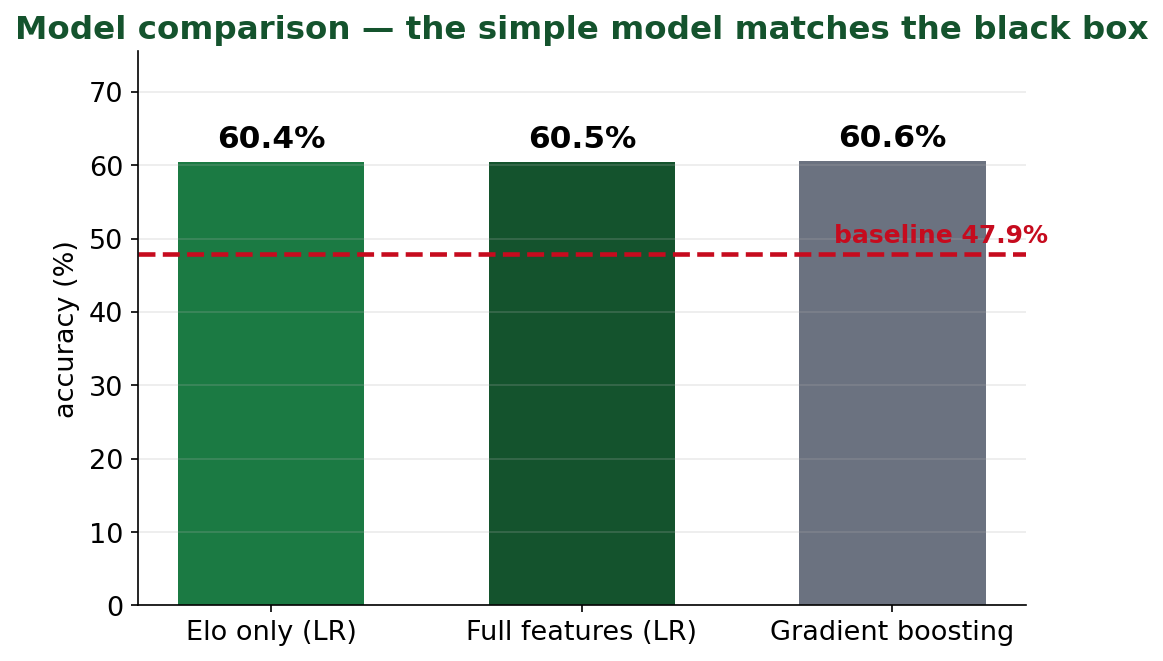

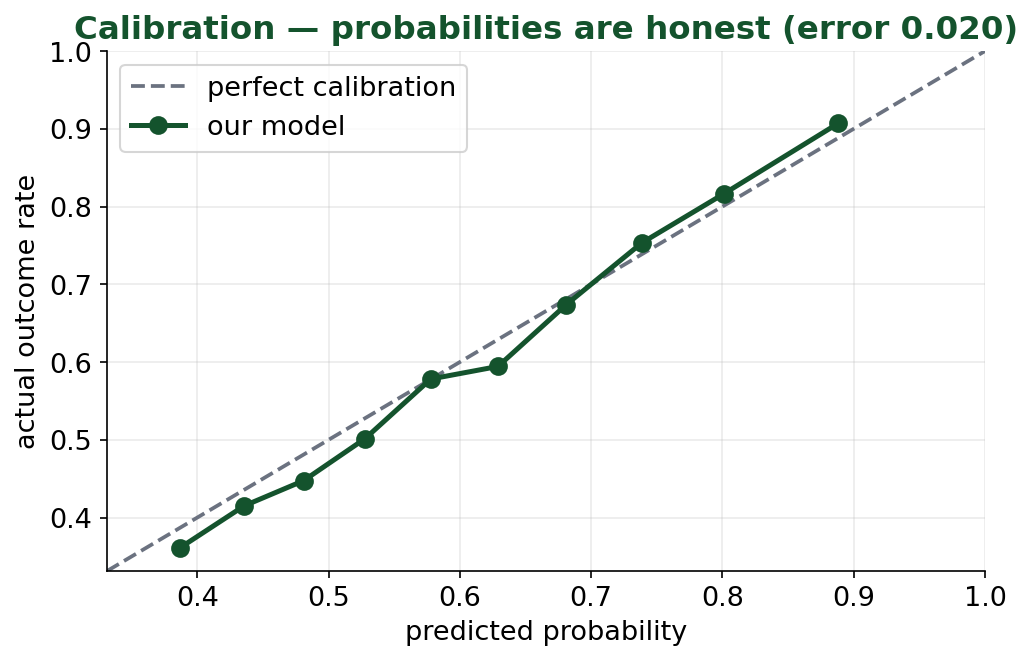

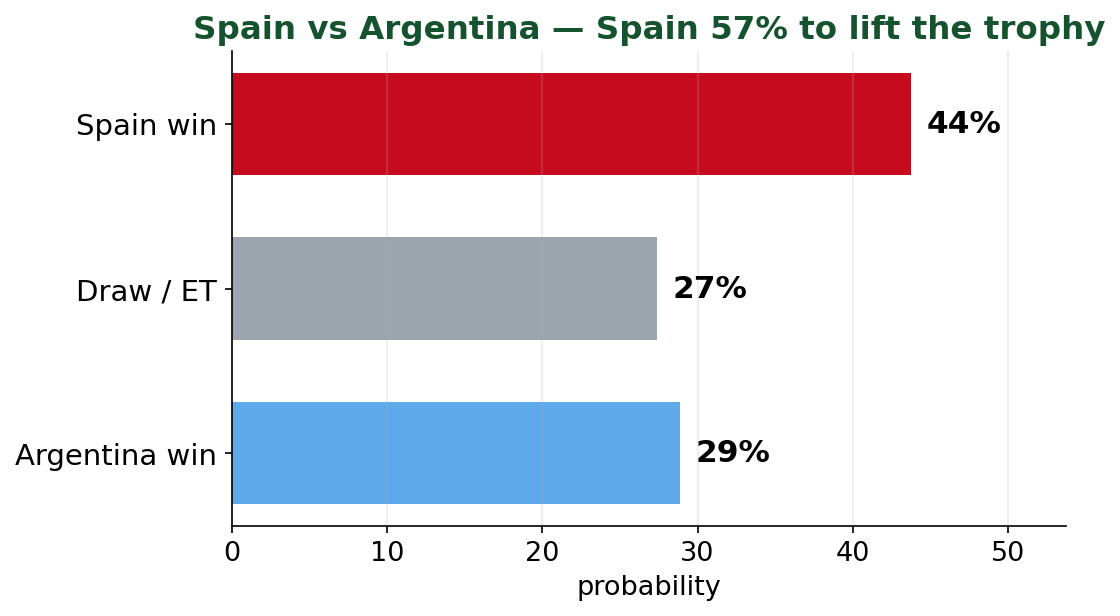

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

GREEN, MID, GOLD, MUTED = "#14532D", "#1B7A43", "#C8890B", "#6B7280"
SPAIN, ARG, DRAW = "#C60B1E", "#5DA9E9", "#9AA5AD"
plt.rcParams.update({"font.size":13,"axes.spines.top":False,"axes.spines.right":False,"figure.dpi":150})

def plot_model_comparison(out, tr, te, save="results_model_comparison.png"):
    base = (te["result"] == tr["result"].mode()[0]).mean()*100
    names = list(out); accs = [out[n]["acc"]*100 for n in names]
    fig, ax = plt.subplots(figsize=(7.0,4.6))
    bars = ax.bar(names, accs, color=[MID,GREEN,MUTED][:len(names)], width=.6)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=15, fontweight="bold", padding=4)
    ax.axhline(base, ls="--", lw=2.2, color=SPAIN)
    ax.text(len(names)-0.5, base+1.6, f"baseline {base:.1f}%", color=SPAIN, ha="right", fontweight="bold", fontsize=12)
    ax.set_ylim(0, max(accs)+15); ax.set_ylabel("accuracy (%)")
    ax.set_title("Model comparison — the simple model matches the black box", color=GREEN, fontweight="bold")
    ax.grid(axis="y", alpha=.25)
    fig.tight_layout(); fig.savefig(save, bbox_inches="tight"); plt.show()

def plot_calibration(model, feats, te, bins=10, save="results_calibration.png"):
    p = model.predict_proba(te[feats]); classes = np.array(model.classes_)
    conf = p.max(1); pred = classes[p.argmax(1)]
    correct = (pred == te["result"].values).astype(float)
    q = pd.qcut(conf, bins, duplicates="drop")
    g = pd.DataFrame({"conf":conf,"correct":correct}).groupby(q, observed=True).agg(
        predicted=("conf","mean"), actual=("correct","mean"), n=("correct","size"))
    ece = (g.n*(g.predicted-g.actual).abs()).sum()/g.n.sum()
    lo = float(min(g.predicted.min(), g.actual.min()))-0.03
    fig, ax = plt.subplots(figsize=(7.0,4.6))
    ax.plot([lo,1],[lo,1], "--", color=MUTED, lw=1.8, label="perfect calibration")
    ax.plot(g.predicted, g.actual, "o-", color=GREEN, lw=2.4, ms=8, label="our model")
    ax.set_xlabel("predicted probability"); ax.set_ylabel("actual outcome rate")
    ax.set_title(f"Calibration — probabilities are honest (error {ece:.3f})", color=GREEN, fontweight="bold")
    ax.set_xlim(lo,1); ax.set_ylim(lo,1); ax.legend(); ax.grid(alpha=.25)
    fig.tight_layout(); fig.savefig(save, bbox_inches="tight"); plt.show()

def plot_final(model, feats, elo, form_state, home="Spain", away="Argentina", neutral=True, save="results_final.png"):
    pts, gd, n = form_state
    row = {"elo_diff": elo[home]-elo[away],
           "form_pts_diff": np.mean(pts.get(home,[1.0])[-n:]) - np.mean(pts.get(away,[1.0])[-n:]),
           "home_form_gd": np.mean(gd.get(home,[0.0])[-n:]),
           "away_form_gd": np.mean(gd.get(away,[0.0])[-n:]),
           "neutral_flag": int(neutral)}
    X = pd.DataFrame([row])[feats]
    p = model.predict_proba(X)[0]; cls = list(model.classes_)
    P = {cls[i]: p[i]*100 for i in range(len(cls))}
    labels = [f"{home} win","Draw / ET",f"{away} win"]; vals = [P["H"],P["D"],P["A"]]; cols = [SPAIN,DRAW,ARG]
    y = np.arange(3)[::-1]
    fig, ax = plt.subplots(figsize=(7.4,4.3))
    ax.barh(y, vals, color=cols, height=.62)
    for yi, v in zip(y, vals): ax.text(v+1, yi, f"{v:.0f}%", va="center", fontweight="bold", fontsize=15)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=14)
    ax.set_xlim(0, max(vals)+10); ax.set_xlabel("probability")
    lift = P["H"] + 0.5*P["D"]
    ax.set_title(f"{home} vs {away} — {home} {lift:.0f}% to lift the trophy", color=GREEN, fontweight="bold")
    ax.grid(axis="x", alpha=.25)
    fig.tight_layout(); fig.savefig(save, bbox_inches="tight"); plt.show()

# uses the variables your predictor cell created:
plot_model_comparison(out, tr, te)
plot_calibration(out[best]["model"], out[best]["feats"], te)
plot_final(out[best]["model"], out[best]["feats"], elo, form_state, "Spain", "Argentina")